In [60]:
import os
import sys
import h5py
# import yaml
# import types
# import torch
import numpy as np
from scipy.io import loadmat
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA
# from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [61]:
REPO_ROOT = os.path.abspath("..")
sys.path.insert(0, REPO_ROOT)

## Load IT neuron firing rate

In [62]:
neural_data_pth = os.path.join(REPO_ROOT, 'data/forJhan/data/MergedITCells_500Stim_AxisTuned.mat')

with h5py.File(neural_data_pth, 'r') as f:
    responses = f['responses']
    # Build full (386 x 500) matrix once
    neural_matrix = np.stack([f[responses[0, i]][()].flatten() for i in range(386)])  # (386, 500)

## Load image embeddings

In [63]:
# alexnet_fc6_latents_mat_pth = os.path.join(REPO_ROOT, 'data/forJhan/data/ObjectSpace/params_Alexnet_fc6_500Stimuli.mat')
# alexnet_fc6_latents = loadmat(alexnet_fc6_latents_mat_pth)['params']

# alexnet_fc6_latents = np.load(os.path.join(REPO_ROOT, "data/stimuli_alexnet_fc6_pca_latents/val_latents.npy"))

In [83]:
# clip_latents = np.load(os.path.join(REPO_ROOT, "data/stimuli_clip_vit_b32_pca_latents/val_latents_z50.npy"))
clip_latents = np.load(os.path.join(REPO_ROOT, "data/stimuli_clip_vit_l14_pca_latents/val_latents.npy"))

In [84]:
clip_latents.shape

(500, 768)

In [65]:
sdvae_latents = np.load(os.path.join(REPO_ROOT, "data/stimuli_sd_vae_latents/val_latents.npy"))

## Axis tuning analysis

For each of the 386 IT neurons, estimate its preferred axis in AlexNet fc6 (PCA'd) space, cross-validated explained variance along that axis, and a selectivity index comparing it to an orthogonal control axis.

In [14]:
from analysis.sta_analysis import (
    compute_population_axis_tuning,
    compute_orthogonal_variance,
    compute_sta,
)
from analysis.visualize_axis_tuning import plot_unit_axis_tuning

In [86]:
# SDVAE_LATENT_SHAPE = sdvae_latents.shape[1:]  # (4, 8, 8) -- needed to unflatten regressed latents back later
# stimuli_embeddings = sdvae_latents.reshape(sdvae_latents.shape[0], -1)  # (500, 256): flatten for axis-tuning/regression

stimuli_embeddings = clip_latents

# axis_tuning_results = compute_population_axis_tuning(
#     neural_matrix, stimuli_embeddings, method='sta'
# )

# ev = axis_tuning_results['explained_variance']
# sel = axis_tuning_results['selectivity_index']

# print(f"Neurons: {neural_matrix.shape[0]}, Stimuli: {neural_matrix.shape[1]}, Feature dims: {stimuli_embeddings.shape[1]}")
# print(f"Mean CV explained variance: {ev.mean():.3f} (median {np.median(ev):.3f})")
# print(f"Mean selectivity index: {sel.mean():.3f} (median {np.median(sel):.3f})")
# print(f"Neurons with EV > 0.1: {(ev > 0.1).sum()}/{len(ev)}")
# print(f"Neurons with EV > 0.1 and selectivity > 0.5: {((ev > 0.1) & (sel > 0.5)).sum()}/{len(ev)}")
# print(f"Mean pairwise preferred-axis angle: {axis_tuning_results['mean_pairwise_angle_deg']:.1f} deg")

In [87]:
# fig, axes_ = plt.subplots(1, 3, figsize=(15, 4))

# axes_[0].hist(ev, bins=30, color='steelblue', edgecolor='black')
# axes_[0].axvline(0.1, color='red', linestyle='--', label='EV = 0.1')
# axes_[0].set_xlabel('Cross-validated EV (preferred axis)')
# axes_[0].set_ylabel('# neurons')
# axes_[0].set_title('Explained variance')
# axes_[0].legend()

# axes_[1].hist(sel, bins=30, color='seagreen', edgecolor='black')
# axes_[1].axvline(0.5, color='red', linestyle='--', label='selectivity = 0.5')
# axes_[1].set_xlabel('Selectivity index')
# axes_[1].set_title('Axis selectivity')
# axes_[1].legend()

# axes_[2].scatter(ev, sel, alpha=0.6, s=20, c=sel, cmap='RdYlGn')
# axes_[2].axhline(0.5, color='red', linestyle='--', linewidth=1)
# axes_[2].axvline(0.1, color='blue', linestyle='--', linewidth=1)
# axes_[2].set_xlabel('Explained variance')
# axes_[2].set_ylabel('Selectivity index')
# axes_[2].set_title('EV vs. selectivity')

# plt.hist(ev, bins=30, color='steelblue', edgecolor='black')
# plt.axvline(0.1, color='red', linestyle='--', label='EV = 0.1')
# plt.xlabel('Cross-validated EV (preferred axis)')
# plt.ylabel('# neurons')
# plt.title('Explained variance')
# plt.legend()

# plt.tight_layout()
# plt.show()

In [88]:
top_units = np.argsort(ev)[-6:][::-1]

# fig, axes_ = plt.subplots(2, 3, figsize=(15, 8))
# for ax, unit_idx in zip(axes_.flatten(), top_units):
#     resp = neural_matrix[unit_idx, :]
#     axis, _ = compute_sta(resp, alexnet_fc6_latents, method='sta', normalize=True)
#     orth = compute_orthogonal_variance(resp, alexnet_fc6_latents, axis)
#     proj_pref = orth['proj_pref']

#     coeffs = np.polyfit(proj_pref, resp, 1)
#     x_sorted = np.sort(proj_pref)
#     ax.scatter(proj_pref, resp, alpha=0.5, s=15, color='gray')
#     ax.plot(x_sorted, np.polyval(coeffs, x_sorted), 'r-', linewidth=2)
#     ax.set_title(f"Neuron {unit_idx}  EV={ev[unit_idx]:.2f}  Sel={sel[unit_idx]:.2f}")
#     ax.set_xlabel('Projection onto preferred axis')
#     ax.set_ylabel('Response')

# plt.tight_layout()
# plt.show()

### Preferred vs. orthogonal axis (3-panel)

For a few top neurons, the full picture: response vs. projection onto the preferred axis (top), response vs. projection onto the orthogonal control axis (left), and the joint 2D scatter colored by response (main). The gradient should run along the preferred axis and be flat along the orthogonal one.

In [89]:
# # for unit_idx in top_units[:3]:
# n = 100
# for unit_idx in range(n, n+3): 
#     resp = neural_matrix[unit_idx, :]
#     plot_unit_axis_tuning(
#         resp,
#         stimuli_embeddings,
#         axis=axis_tuning_results['axes'][unit_idx],
#         response_label='Response (a.u.)',
#         title=f"Neuron {unit_idx}  EV={ev[unit_idx]:.2f}  Sel={sel[unit_idx]:.2f}",
#     )
#     plt.show()

### Rank of preferred-axis matrix W

Each row of `W` is one neuron's preferred axis in the (flattened) embedding space. Recovering a stimulus embedding from the population response requires `rank(W) = n_features` (see population axis-tuning discussion) — otherwise some embedding directions lie in `W`'s null space and are invisible to the whole population regardless of neuron count.</cell id="df5a18b6">


In [90]:
# W = axis_tuning_results['axes']  # (386 neurons, 50 feature dims)
# rank_W = np.linalg.matrix_rank(W)

# print(f"W shape: {W.shape}")
# print(f"rank(W) = {rank_W} (full column rank = {W.shape[1]})")
# print(f"Null space dimension: {W.shape[1] - rank_W}")

## Firing rates $\to$ image embeddings

In [91]:
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from analysis.sta_analysis import compute_explained_variance

In [92]:
def evaluate(y_pred, label):
    dim_ev = np.array([compute_explained_variance(y_test[:, d], y_pred[:, d]) for d in range(y_test.shape[1])])
    overall_ev = compute_explained_variance(y_test.flatten(), y_pred.flatten())
    print(f"{label}: held-out EV (flattened):={overall_ev:.3f}") 
    print(f"Per-dimension EV: mean={dim_ev.mean():.3f}, median={np.median(dim_ev):.3f}") 
    print(f"Dimensions with EV > 0.1: {int((dim_ev>0.1).sum())}/{len(dim_ev)}")
    return dim_ev

In [93]:
# Train/test split over the 500 stimuli
rng = np.random.default_rng(0)
n_stim = neural_matrix.shape[1]
perm = rng.permutation(n_stim)
n_test = int(0.2 * n_stim)
test_idx, train_idx = perm[:n_test], perm[n_test:]

X_train, X_test = neural_matrix[:, train_idx].T, neural_matrix[:, test_idx].T  # (n_stim, 386 neurons)
y_train, y_test = stimuli_embeddings[train_idx], stimuli_embeddings[test_idx]  # (n_stim, n_features), flattened

In [94]:
# # original: unscaled, fixed alpha=100
# d1 = Ridge(alpha=100.0).fit(X_train, y_train)
# evaluate(d1.predict(X_test), "raw Ridge alpha=100")

# # standardized features, same fixed alpha
# pipe = make_pipeline(StandardScaler(), Ridge(alpha=100.0)).fit(X_train, y_train)
# evaluate(pipe.predict(X_test), "scaled Ridge alpha=100")

# standardize, then PCA the neural features down before regressing -- n_train (400) and
# p_features (386) are close enough that raw Ridge sees a near-collinear, poorly
# conditioned design matrix; PCA gives it fewer, decorrelated directions to regularize over
N_NEURAL_PCA_COMPONENTS = 100  # tune against the explained-variance printout below

scaler = StandardScaler().fit(X_train)
Xtr_scaled, Xte_scaled = scaler.transform(X_train), scaler.transform(X_test)

neural_pca = PCA(n_components=N_NEURAL_PCA_COMPONENTS, random_state=0).fit(Xtr_scaled)
Xtr_s, Xte_s = neural_pca.transform(Xtr_scaled), neural_pca.transform(Xte_scaled)

print(f"Neural PCA: {X_train.shape[1]} neurons -> {N_NEURAL_PCA_COMPONENTS} components "
      f"(explained variance retained: {neural_pca.explained_variance_ratio_.sum():.3f})")

Neural PCA: 386 neurons -> 100 components (explained variance retained: 0.767)


In [95]:
# cross-validated alpha per target dimension, now on the PCA'd neural features
rcv = RidgeCV(alphas=np.logspace(-1, 6, 30), alpha_per_target=True).fit(Xtr_s, y_train)
y_pred = rcv.predict(Xte_s)
dim_ev = evaluate(y_pred, "PCA + scaled RidgeCV (alpha_per_target)")
print("chosen alphas range:", rcv.alpha_.min(), rcv.alpha_.max())

PCA + scaled RidgeCV (alpha_per_target): held-out EV (flattened):=0.666
Per-dimension EV: mean=0.122, median=0.107
Dimensions with EV > 0.1: 399/768
chosen alphas range: 417.53189365604044 11721.022975334818


In [96]:
y_fit = rcv.predict(Xtr_s)

In [99]:
# np.save(
#     os.path.join(REPO_ROOT, "data/stimuli_sd_vae_latents/train_regressed_latents.npy"), 
#     y_fit.reshape(-1, *SDVAE_LATENT_SHAPE)
# )
# np.save(
#     os.path.join(REPO_ROOT, "data/stimuli_sd_vae_latents/test_regressed_latents.npy"), 
#     y_pred.reshape(-1, *SDVAE_LATENT_SHAPE)
# )

np.save(os.path.join(REPO_ROOT, "data/stimuli_clip_vit_l14_pca_latents/train_regressed_latents.npy"), y_fit)
np.save(os.path.join(REPO_ROOT, "data/stimuli_clip_vit_l14_pca_latents/test_regressed_latents.npy"), y_pred)

In [45]:
# # 1. How many dimensions are hitting the boundary?
# at_max = np.sum(rcv.alpha_ >= 1e6)
# print(f"{at_max}/{len(rcv.alpha_)} dimensions hit the alpha ceiling")

# # 2. Extend the grid dramatically and see if it keeps climbing
# rcv2 = RidgeCV(alphas=np.logspace(-1, 10, 40), alpha_per_target=True).fit(Xtr_s, y_train)
# print("new alpha range:", rcv2.alpha_.min(), rcv2.alpha_.max())
# still_at_max = np.sum(rcv2.alpha_ >= 1e10)
# print(f"{still_at_max} still climbing")

# # 3. Cross-reference chosen alpha with per-dim EV
# from sklearn.metrics import r2_score
# per_dim_ev = 1 - np.var(y_test - y_pred, axis=0) / np.var(y_test, axis=0)
# import scipy.stats as ss
# corr, p = ss.spearmanr(rcv.alpha_, per_dim_ev)
# print(f"correlation between chosen alpha and per-dim EV: {corr:.3f}")

# # 4. Check n vs p
# print(f"n_train={X_train.shape[0]}, p_features={X_train.shape[1]}")

# # 5. Condition number of scaled X (multicollinearity check)
# print("condition number:", np.linalg.cond(Xtr_s))

In [46]:
# # Regression predicts/targets flattened (n_stim, 256) embeddings -- unflatten back to
# # sd_vae's native (4, 8, 8) latent shape so they can be fed straight into the VAE's
# # decoder (see extract_batch.decode in notebooks/extract_image_embeddings.ipynb).
# y_pred_latent = y_pred.reshape(-1, *SDVAE_LATENT_SHAPE)
# y_test_latent = y_test.reshape(-1, *SDVAE_LATENT_SHAPE)
# print(f"Unflattened regressed latents: {y_pred_latent.shape}")

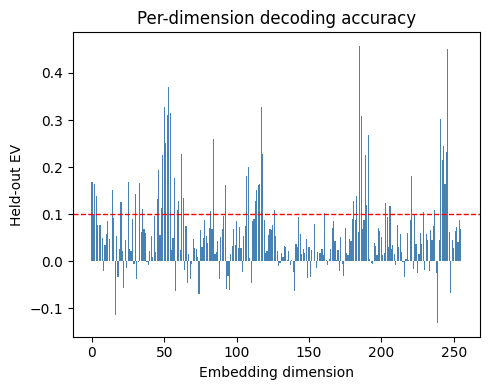

In [52]:
plt.figure(figsize=(5, 4))
plt.bar(np.arange(len(dim_ev)), dim_ev, color='steelblue')
plt.axhline(0.1, color='red', linestyle='--', linewidth=1)
plt.xlabel('Embedding dimension')
plt.ylabel('Held-out EV')
plt.title('Per-dimension decoding accuracy')
plt.tight_layout()
plt.show()

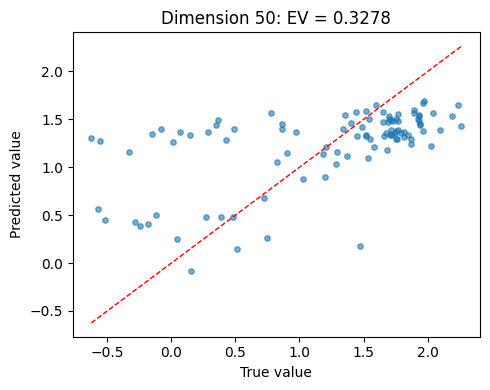

In [59]:
example_dim = 50
plt.figure(figsize=(5, 4))
plt.scatter(y_test[:, example_dim], y_pred[:, example_dim], alpha=0.6, s=15)
lims = [min(y_test[:, example_dim].min(), y_pred[:, example_dim].min()), max(y_test[:, example_dim].max(), y_pred[:, example_dim].max())]
plt.plot(lims, lims, 'r--', linewidth=1)
plt.xlabel(f'True value')
plt.ylabel(f'Predicted value')
plt.title(f'Dimension {example_dim}: EV = {dim_ev[example_dim]:.4f}')
plt.tight_layout()
plt.show()